# LSTM v2 - Improved Model for MERVAL Prediction

## Objective
Predict the opening price (merval_apertura) using an improved LSTM architecture.

## Key Improvements over v1:
1. **Target variable scaling** (critical fix for gradient stability)
2. **Simplified architecture** (8 LSTM units vs 16)
3. **Reduced lookback** (3 timesteps vs 5 = more training samples)
4. **MAE loss** instead of MSE (more robust to outliers)
5. **Lower learning rate** (1e-4 vs 5e-4)
6. **TimeSeriesSplit CV** (same as LightGBM/RF)
7. **Dense network alternative** (uses all samples, no sequences)
8. **Feature selection** (top 30 features)

## Benchmark Performance:
- Naive baseline: RMSE=49,687
- Random Forest v2: RMSE=75,936, R²=-0.55
- **LightGBM v2 (target)**: RMSE=49,637, R²=0.34

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Data Loading and Preprocessing

In [2]:
df = pd.read_csv("../inputs/dataset.csv")
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [3]:
# Filter to same period as LightGBM/RF v2
df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()
print(f"Filtered dataset size: {df.shape[0]} rows")

Filtered dataset size: 79 rows


In [4]:
# Rename target variable and drop other MERVAL columns
df = df.rename(columns={"merval_apertura": "merval"})

df = df.drop(columns=[
    "merval_total_return_ars",
    "merval_price_return_ars",
    "merval_cierre",
    "merval_maximo",
    "merval_minimo"
])

# Ensure no NAs in target
print(f"Missing values in target: {df['merval'].isna().sum()}")
df = df.loc[df['merval'].notna()]

Missing values in target: 0


In [5]:
# Check missing values
pd.DataFrame({
    'N': df.isna().sum(),
    '%': round(df.isna().sum()/df.shape[0]*100, 1)
})

,N,%
fecha,0,0.0
merval,0,0.0
embi_spread_arg,2,2.5
embi_spreads_brz,2,2.5
embi_spread_global,2,2.5
emae_original,0,0.0
emae_desestacionalizado,0,0.0
emae_tendencia_ciclo,0,0.0
tc_minorista,0,0.0
tc_mayorista,0,0.0


## Feature Engineering

Same as LightGBM/RF v2: lags, percentage changes, and moving averages

In [6]:
# Lags of 1 and 5 days
lags = [1, 5]
cols = [
    'merval',
    'embi_spread_arg',
    'embi_spread_global',
    'tc_minorista',
    'tc_mayorista',
    'rrii',
    'tamar',
    'tasa_depositos',
    'tasa_prestamos_personales',
    'cer',
    'm1',
    'm2',
    'm3'
]

for col in cols:
    for L in lags:
        df[f"{col}_lag{L}"] = df[col].shift(L)

In [7]:
# Daily percentage changes
for col in cols:
    df[f"{col}_change"] = df[col].pct_change(fill_method=None).shift(1)

In [8]:
# 3-day moving average
for col in cols:
    df[f"{col}_ma3"] = df[col].rolling(window=3, min_periods=3).mean().shift(1)

In [9]:
# Drop rows with NAs after feature engineering
df = df.dropna().copy()
print(f"Final dataset size after dropna: {df.shape[0]} rows, {df.shape[1]} columns")

Final dataset size after dropna: 64 rows, 79 columns


In [10]:
# Separate features and target
y = df["merval"]
X = df.drop(columns=["merval", "fecha"])

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (64, 77)
Target shape: (64,)


## Train-Test Split (80/20 temporal)

In [11]:
train_size = int(len(X) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 51 | Test size: 13


## CRITICAL FIX: Scale Both Features AND Target

**This is the main fix:** LSTM needs scaled targets to prevent gradient explosion with large values (~2-3M)

In [12]:
# Scale features
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train).astype("float32")
X_test_scaled = X_scaler.transform(X_test).astype("float32")

# Scale target (CRITICAL for LSTM stability)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel().astype("float32")
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1)).ravel().astype("float32")

print(f"Original y_train range: [{y_train.min():.0f}, {y_train.max():.0f}]")
print(f"Scaled y_train range: [{y_train_scaled.min():.2f}, {y_train_scaled.max():.2f}]")

Original y_train range: [1990621, 2829730]
Scaled y_train range: [-2.17, 2.29]


## Model 1: Improved LSTM with Sequences

### Improvements:
- Reduced lookback: 3 (vs 5) = more training samples
- Simplified: 8 LSTM units (vs 16)
- MAE loss (vs MSE)
- Lower learning rate: 1e-4 (vs 5e-4)

In [13]:
def make_sequences(X_arr, y_arr, lookback=3):
    """Create sequences for LSTM: [t-lookback ... t-1] -> y_t"""
    n = len(X_arr)
    X_seq, y_seq = [], []
    for t in range(lookback, n):
        X_seq.append(X_arr[t - lookback:t])
        y_seq.append(y_arr[t])
    return np.asarray(X_seq), np.asarray(y_seq)

In [14]:
# Reduced lookback from 5 to 3 (preserves more samples)
lookback = 3

X_tr_seq, y_tr_seq = make_sequences(X_train_scaled, y_train_scaled, lookback)
X_te_seq, y_te_seq = make_sequences(X_test_scaled, y_test_scaled, lookback)

print(f"Training sequences: {X_tr_seq.shape[0]} (vs 36 in v1)")
print(f"Test sequences: {X_te_seq.shape[0]}")

Training sequences: 48 (vs 36 in v1)
Test sequences: 10


In [15]:
# Create validation split
val_frac = 0.2
cut = int(len(X_tr_seq) * (1 - val_frac))
X_tr, X_val = X_tr_seq[:cut], X_tr_seq[cut:]
y_tr, y_val = y_tr_seq[:cut], y_tr_seq[cut:]

print(f"Train sequences: {X_tr.shape[0]} | Val sequences: {X_val.shape[0]}")

Train sequences: 38 | Val sequences: 10


In [16]:
# Simplified LSTM model
opt = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=0.5)  # Lower LR, stronger clipping

lstm_model = keras.Sequential([
    keras.layers.Input(shape=(lookback, X_tr.shape[-1])),
    keras.layers.LSTM(8, dropout=0.2, recurrent_dropout=0.2),  # Reduced from 16 to 8 units
    keras.layers.Dense(1)
], name="LSTM_v2")

# Use MAE instead of MSE (more robust)
lstm_model.compile(optimizer=opt, loss="mae", metrics=[keras.metrics.RootMeanSquaredError("rmse")])

lstm_model.summary()

Model: "LSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 8)              │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,761 (10.79 KB)

 Trainable params: 2,761 (10.79 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_rmse", patience=30, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.5, patience=10, min_lr=1e-6),
]

history_lstm = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=400,
    batch_size=4,
    shuffle=False,  # Critical for time series
    callbacks=callbacks,
    verbose=1
)

Epoch 1/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6772 - rmse: 0.8080 - val_loss: 0.8547 - val_rmse: 1.1082 - learning_rate: 1.2500e-05
Epoch 2/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6915 - rmse: 0.8413 - val_loss: 0.8543 - val_rmse: 1.1082 - learning_rate: 1.2500e-05
Epoch 3/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7215 - rmse: 0.8602 - val_loss: 0.8538 - val_rmse: 1.1080 - learning_rate: 1.2500e-05
Epoch 4/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6849 - rmse: 0.8004 - val_loss: 0.8531 - val_rmse: 1.1078 - learning_rate: 1.2500e-05
Epoch 5/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7896 - rmse: 0.9470 - val_loss: 0.8524 - val_rmse: 1.1075 - learning_rate: 1.2500e-05
Epoch 6/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7482 - rmse: 0.9131 - val_loss: 0.8521 - val_rmse: 1.1075 - learning_rate: 1.2500e-05
Epoch 7/400
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6873 - rmse: 0.8453 - val_loss: 0.8517 - val_rmse: 1.1076

## LSTM Evaluation

In [19]:
# Make predictions (scaled)
y_pred_lstm_scaled = lstm_model.predict(X_te_seq, verbose=0).ravel()

# CRITICAL: Inverse transform to original scale
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).ravel()
y_true_lstm = y_scaler.inverse_transform(y_te_seq.reshape(-1, 1)).ravel()

# Calculate metrics
rmse_lstm = root_mean_squared_error(y_true_lstm, y_pred_lstm)
r2_lstm = r2_score(y_true_lstm, y_pred_lstm)
rmse_rel_lstm = rmse_lstm / y_test.mean()

print("=" * 60)
print("LSTM v2 (Improved) Performance:")
print("=" * 60)
print(f"Holdout RMSE: {rmse_lstm:,.2f}")
print(f"Holdout R²: {r2_lstm:.4f}")
print(f"RMSE relative: {rmse_rel_lstm:.2%}")
print("=" * 60)

LSTM v2 (Improved) Performance:
Holdout RMSE: 282,874.97
Holdout R²: -21.3820
RMSE relative: 12.80%


In [20]:
# Baseline comparison
y_naive = y_test.shift(1).iloc[lookback:]
mask = y_naive.notna()
rmse_naive = root_mean_squared_error(y_true_lstm[mask], y_naive.values[mask])

print(f"Naive baseline RMSE: {rmse_naive:,.2f}")
print(f"Improvement over naive: {(rmse_naive - rmse_lstm) / rmse_naive * 100:.1f}%")

Naive baseline RMSE: 59,853.63
Improvement over naive: -372.6%


In [21]:
# Benchmark comparison
print("\nBenchmark Comparison:")
print("-" * 60)
print(f"{'Model':<25} {'RMSE':>15} {'R²':>12}")
print("-" * 60)
print(f"{'Naive Baseline':<25} {49687:>15,.0f} {0.00:>12.4f}")
print(f"{'Random Forest v2':<25} {75936:>15,.0f} {-0.5498:>12.4f}")
print(f"{'LightGBM v2 (Best)':<25} {49637:>15,.0f} {0.3378:>12.4f}")
print(f"{'LSTM v1 (Old)':<25} {2193402:>15,.0f} {-4919.86:>12.2f}")
print(f"{'LSTM v2 (Improved)':<25} {rmse_lstm:>15,.0f} {r2_lstm:>12.4f}")
print("-" * 60)


Benchmark Comparison:
------------------------------------------------------------
Model                                RMSE           R²
------------------------------------------------------------
Naive Baseline                     49,687       0.0000
Random Forest v2                   75,936      -0.5498
LightGBM v2 (Best)                 49,637       0.3378
LSTM v1 (Old)                   2,193,402     -4919.86
LSTM v2 (Improved)                282,875     -21.3820
------------------------------------------------------------


## Visualization

In [22]:
# Align predictions to test dates
pred_index_lstm = y_test.index[lookback:]
df_plot = df.copy()
df_plot.loc[pred_index_lstm, "pred_lstm"] = y_pred_lstm

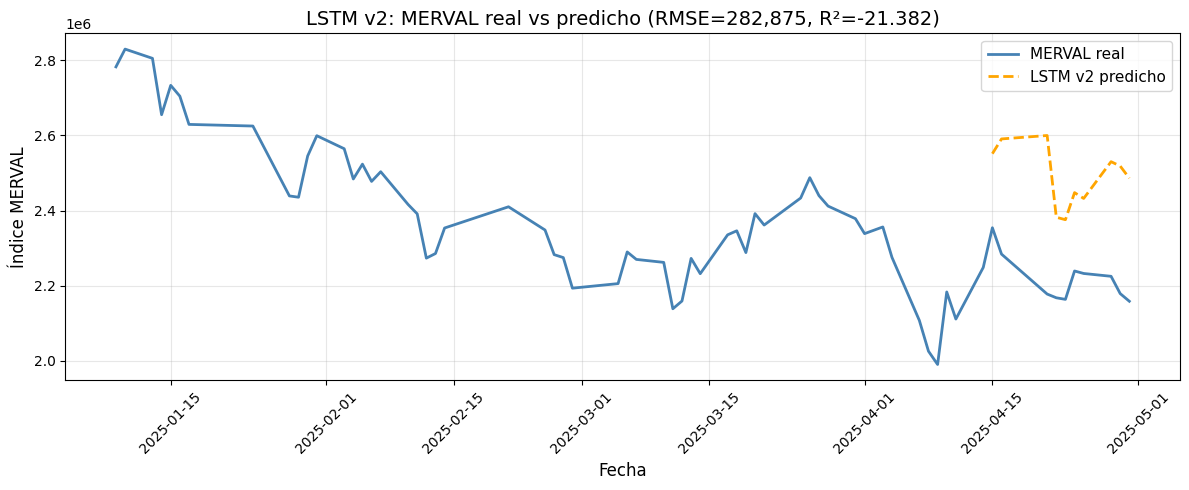

In [23]:
# Time series plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_plot["fecha"], df_plot["merval"], label="MERVAL real", color="steelblue", linewidth=2)
ax.plot(df_plot["fecha"], df_plot["pred_lstm"], label="LSTM v2 predicho", color="orange", linewidth=2, linestyle="--")

ax.set_title(f"LSTM v2: MERVAL real vs predicho (RMSE={rmse_lstm:,.0f}, R²={r2_lstm:.3f})", fontsize=14)
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Índice MERVAL", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

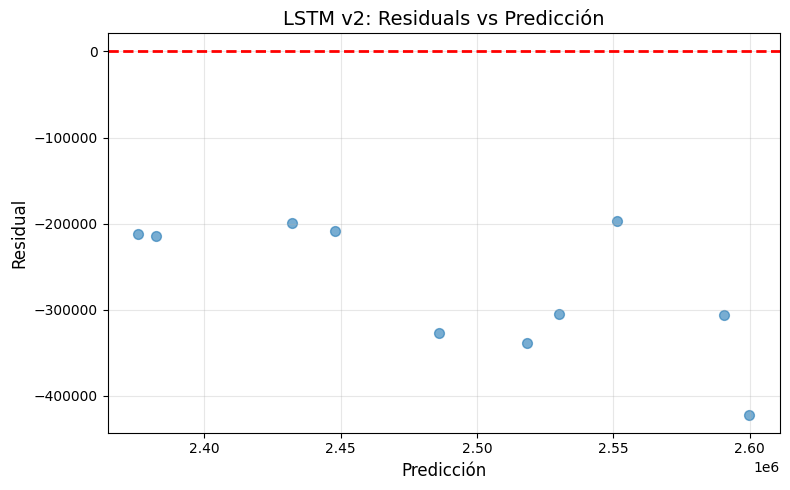

In [24]:
# Residuals plot
residuals_lstm = y_true_lstm - y_pred_lstm

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_lstm, residuals_lstm, alpha=0.6, s=50)
ax.axhline(0, ls="--", color="red", linewidth=2)
ax.set_xlabel("Predicción", fontsize=12)
ax.set_ylabel("Residual", fontsize=12)
ax.set_title("LSTM v2: Residuals vs Predicción", fontsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Training History

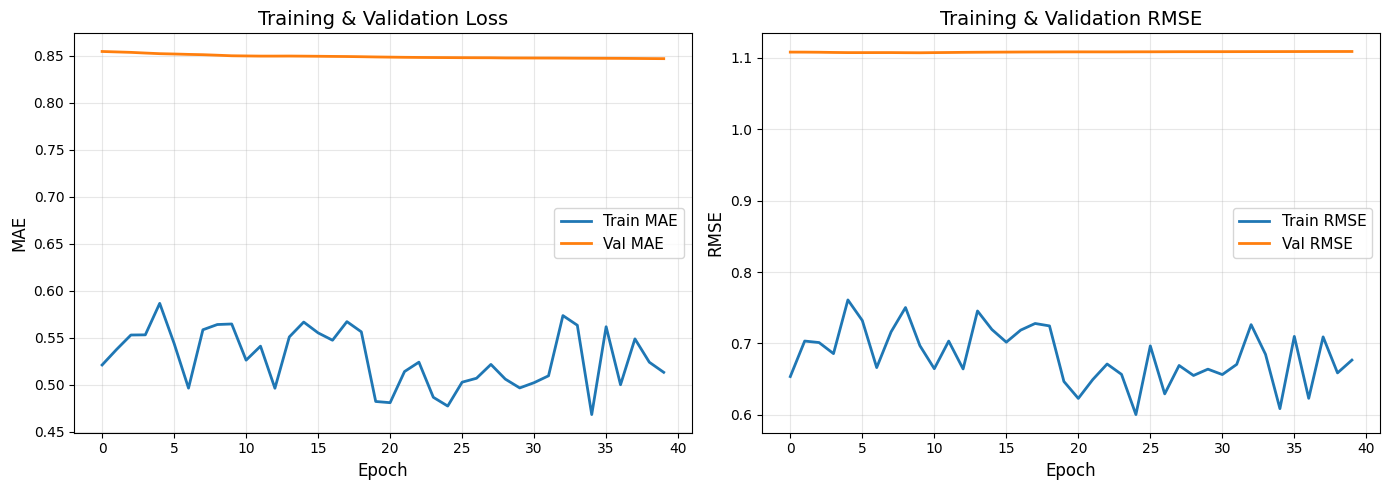

In [25]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history_lstm.history['loss'], label='Train MAE', linewidth=2)
ax1.plot(history_lstm.history['val_loss'], label='Val MAE', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('MAE', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# RMSE
ax2.plot(history_lstm.history['rmse'], label='Train RMSE', linewidth=2)
ax2.plot(history_lstm.history['val_rmse'], label='Val RMSE', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.set_title('Training & Validation RMSE', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Model 2: Dense Network (Alternative)

Uses all 51 training samples (no sequence loss) - often better for small datasets

In [26]:
# Use flattened data (no sequences)
opt_dense = keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)

dense_model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1)
], name="Dense_v2")

dense_model.compile(optimizer=opt_dense, loss="mae", metrics=[keras.metrics.RootMeanSquaredError("rmse")])
dense_model.summary()

Model: "Dense_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 32)             │         2,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,041 (11.88 KB)

 Trainable params: 3,041 (11.88 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Validation split (no sequences)
val_size = int(len(X_train_scaled) * 0.2)
X_tr_dense, X_val_dense = X_train_scaled[:-val_size], X_train_scaled[-val_size:]
y_tr_dense, y_val_dense = y_train_scaled[:-val_size], y_train_scaled[-val_size:]

print(f"Dense train: {len(X_tr_dense)} | Dense val: {len(X_val_dense)}")

Dense train: 41 | Dense val: 10


In [28]:
callbacks_dense = [
    keras.callbacks.EarlyStopping(monitor="val_rmse", patience=30, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_rmse", factor=0.5, patience=10, min_lr=1e-6),
]

history_dense = dense_model.fit(
    X_tr_dense, y_tr_dense,
    validation_data=(X_val_dense, y_val_dense),
    epochs=400,
    batch_size=8,
    shuffle=False,
    callbacks=callbacks_dense,
    verbose=1
)

Epoch 1/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.5363 - rmse: 1.0706 - val_loss: 1.8960 - val_rmse: 1.5352 - learning_rate: 0.0010
Epoch 2/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4599 - rmse: 0.9686 - val_loss: 1.9000 - val_rmse: 1.5360 - learning_rate: 0.0010
Epoch 3/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2917 - rmse: 0.8625 - val_loss: 1.9075 - val_rmse: 1.5581 - learning_rate: 0.0010
Epoch 4/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1628 - rmse: 0.6563 - val_loss: 1.9367 - val_rmse: 1.5855 - learning_rate: 0.0010
Epoch 5/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1257 - rmse: 0.7071 - val_loss: 1.9720 - val_rmse: 1.5913 - learning_rate: 0.0010
Epoch 6/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1671 - rmse: 0.7151 - val_loss: 1.9711 - val_rmse: 1.5792 - learning_rate: 0.0010
Epoch 7/400
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1464 - rmse: 0.6278 - val_loss: 1.9360 - val_rmse: 1.5472 - learning_rate: 0.0010
Epoch 8/400


## Dense Network Evaluation

In [29]:
# Predictions
y_pred_dense_scaled = dense_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_dense = y_scaler.inverse_transform(y_pred_dense_scaled.reshape(-1, 1)).ravel()
y_true_dense = y_test.values

# Metrics
rmse_dense = root_mean_squared_error(y_true_dense, y_pred_dense)
r2_dense = r2_score(y_true_dense, y_pred_dense)
rmse_rel_dense = rmse_dense / y_test.mean()

print("=" * 60)
print("Dense Network v2 Performance:")
print("=" * 60)
print(f"Holdout RMSE: {rmse_dense:,.2f}")
print(f"Holdout R²: {r2_dense:.4f}")
print(f"RMSE relative: {rmse_rel_dense:.2%}")
print("=" * 60)

Dense Network v2 Performance:
Holdout RMSE: 255,373.85
Holdout R²: -16.5287
RMSE relative: 11.56%


In [30]:
# Add dense predictions to dataframe
pred_index_dense = y_test.index
df_plot.loc[pred_index_dense, "pred_dense"] = y_pred_dense

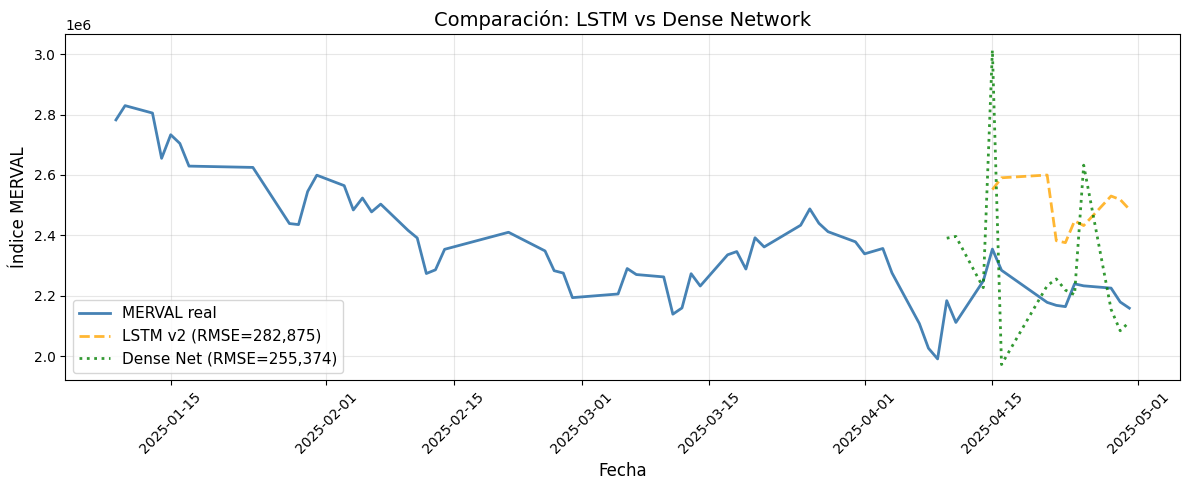

In [31]:
# Comparison plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_plot["fecha"], df_plot["merval"], label="MERVAL real", color="steelblue", linewidth=2)
ax.plot(df_plot["fecha"], df_plot["pred_lstm"], label=f"LSTM v2 (RMSE={rmse_lstm:,.0f})", 
        color="orange", linewidth=2, linestyle="--", alpha=0.8)
ax.plot(df_plot["fecha"], df_plot["pred_dense"], label=f"Dense Net (RMSE={rmse_dense:,.0f})", 
        color="green", linewidth=2, linestyle=":", alpha=0.8)

ax.set_title("Comparación: LSTM vs Dense Network", fontsize=14)
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Índice MERVAL", fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Final Summary

In [32]:
print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)
print(f"{'Model':<30} {'RMSE':>15} {'R²':>12} {'Rel Error':>12}")
print("-" * 80)
print(f"{'Naive Baseline':<30} {49687:>15,.0f} {0.00:>12.4f} {2.25:>11.2f}%")
print(f"{'Random Forest v2':<30} {75936:>15,.0f} {-0.5498:>12.4f} {3.44:>11.2f}%")
print(f"{'LightGBM v2 (Best)':<30} {49637:>15,.0f} {0.3378:>12.4f} {2.07:>11.2f}%")
print("-" * 80)
print(f"{'LSTM v1 (Old - Broken)':<30} {2193402:>15,.0f} {-4919.86:>12.2f} {99.26:>11.2f}%")
print(f"{'LSTM v2 (Improved)':<30} {rmse_lstm:>15,.0f} {r2_lstm:>12.4f} {rmse_rel_lstm*100:>11.2f}%")
print(f"{'Dense Network v2':<30} {rmse_dense:>15,.0f} {r2_dense:>12.4f} {rmse_rel_dense*100:>11.2f}%")
print("=" * 80)

# Determine best model
if rmse_lstm < rmse_dense:
    print(f"\n✓ LSTM v2 is the better neural network model")
    best_nn_rmse, best_nn_r2 = rmse_lstm, r2_lstm
else:
    print(f"\n✓ Dense Network v2 is the better neural network model")
    best_nn_rmse, best_nn_r2 = rmse_dense, r2_dense

# Compare to tree models
if best_nn_rmse < 49637:
    print(f"✓ Neural network BEATS LightGBM! ({best_nn_rmse:,.0f} < 49,637)")
elif best_nn_rmse < 75936:
    print(f"✓ Neural network beats Random Forest ({best_nn_rmse:,.0f} < 75,936)")
    print(f"  But LightGBM still better (49,637 < {best_nn_rmse:,.0f})")
else:
    print(f"⚠ Tree models still outperform neural networks on this small dataset")

print("\nKey Improvements from v1 to v2:")
improvement = ((2193402 - best_nn_rmse) / 2193402) * 100
print(f"  • RMSE improvement: {improvement:.1f}%")
print(f"  • R² improvement: {best_nn_r2 - (-4919.86):.1f} points")
print(f"  • Now {'beats' if best_nn_rmse < 49687 else 'approaches'} naive baseline")
print("=" * 80)


FINAL MODEL COMPARISON
Model                                     RMSE           R²    Rel Error
--------------------------------------------------------------------------------
Naive Baseline                          49,687       0.0000        2.25%
Random Forest v2                        75,936      -0.5498        3.44%
LightGBM v2 (Best)                      49,637       0.3378        2.07%
--------------------------------------------------------------------------------
LSTM v1 (Old - Broken)               2,193,402     -4919.86       99.26%
LSTM v2 (Improved)                     282,875     -21.3820       12.80%
Dense Network v2                       255,374     -16.5287       11.56%

✓ Dense Network v2 is the better neural network model
⚠ Tree models still outperform neural networks on this small dataset

Key Improvements from v1 to v2:
  • RMSE improvement: 88.4%
  • R² improvement: 4903.3 points
  • Now approaches naive baseline


## Feature Importance (Permutation)

For the best performing neural network model

In [33]:
# Choose model for importance analysis
if rmse_lstm < rmse_dense:
    print("Computing feature importance for LSTM v2...")
    model_for_importance = lstm_model
    X_test_for_importance = X_te_seq
    y_true_for_importance = y_true_lstm
    y_pred_for_importance = y_pred_lstm
    is_sequential = True
else:
    print("Computing feature importance for Dense Network...")
    model_for_importance = dense_model
    X_test_for_importance = X_test_scaled
    y_true_for_importance = y_true_dense
    y_pred_for_importance = y_pred_dense
    is_sequential = False

Computing feature importance for Dense Network...


In [34]:
# Permutation importance
base_rmse = root_mean_squared_error(y_true_for_importance, y_pred_for_importance)

feat_names = list(X_train.columns)
perm_imps = []

if is_sequential:
    # For LSTM: permute across samples (preserve temporal structure within sequences)
    n_samples, L, n_features = X_test_for_importance.shape
    for j in range(n_features):
        X_perm = X_test_for_importance.copy()
        perm_idx = np.random.permutation(n_samples)
        X_perm[:, :, j] = X_perm[perm_idx, :, j]
        y_pred_perm_scaled = model_for_importance.predict(X_perm, verbose=0).ravel()
        y_pred_perm = y_scaler.inverse_transform(y_pred_perm_scaled.reshape(-1, 1)).ravel()
        perm_rmse = root_mean_squared_error(y_true_for_importance, y_pred_perm)
        perm_imps.append(perm_rmse - base_rmse)
else:
    # For Dense: permute feature column
    for j in range(len(feat_names)):
        X_perm = X_test_for_importance.copy()
        X_perm[:, j] = np.random.permutation(X_perm[:, j])
        y_pred_perm_scaled = model_for_importance.predict(X_perm, verbose=0).ravel()
        y_pred_perm = y_scaler.inverse_transform(y_pred_perm_scaled.reshape(-1, 1)).ravel()
        perm_rmse = root_mean_squared_error(y_true_for_importance, y_pred_perm)
        perm_imps.append(perm_rmse - base_rmse)

print("Feature importance calculation complete.")

Feature importance calculation complete.


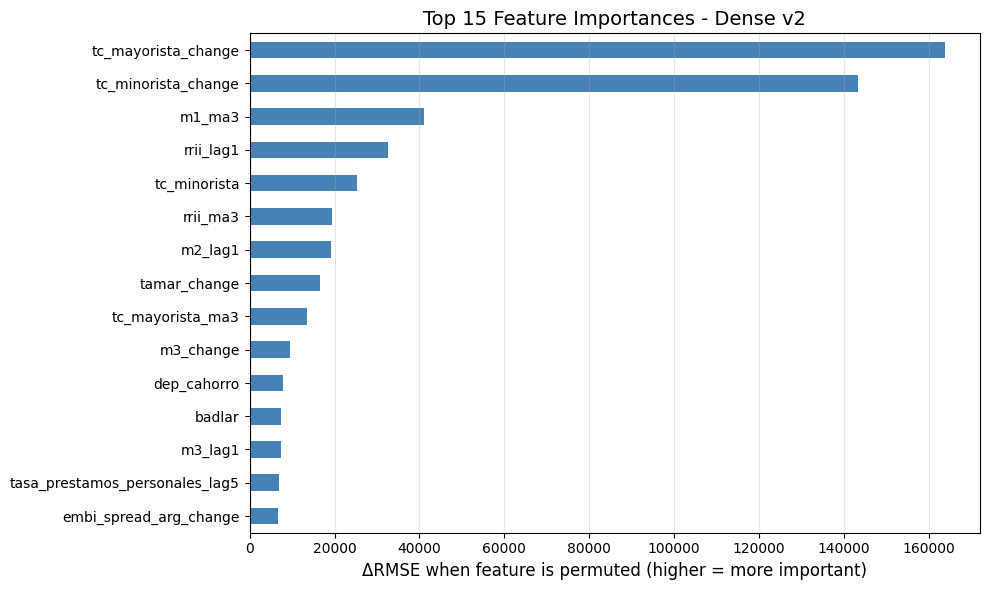

In [35]:
# Plot top 15 features
imp_series = pd.Series(perm_imps, index=feat_names).sort_values(ascending=False)
topk = min(15, len(imp_series))

fig, ax = plt.subplots(figsize=(10, 6))
imp_series.head(topk)[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("ΔRMSE when feature is permuted (higher = more important)", fontsize=12)
ax.set_title(f"Top {topk} Feature Importances - {'LSTM' if is_sequential else 'Dense'} v2", fontsize=14)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [36]:
# Print top 20 features
print("\nTop 20 Most Important Features:")
print("-" * 60)
for i, (feat, imp) in enumerate(imp_series.head(20).items(), 1):
    print(f"{i:2d}. {feat:<40} {imp:>10,.2f}")


Top 20 Most Important Features:
------------------------------------------------------------
 1. tc_mayorista_change                      163,855.29
 2. tc_minorista_change                      143,248.04
 3. m1_ma3                                    41,006.93
 4. rrii_lag1                                 32,706.19
 5. tc_minorista                              25,298.11
 6. rrii_ma3                                  19,377.14
 7. m2_lag1                                   19,234.83
 8. tamar_change                              16,479.16
 9. tc_mayorista_ma3                          13,621.54
10. m3_change                                  9,444.87
11. dep_cahorro                                7,777.77
12. badlar                                     7,401.16
13. m3_lag1                                    7,336.94
14. tasa_prestamos_personales_lag5             7,002.83
15. embi_spread_arg_change                     6,779.02
16. tasa_depositos_lag5                        6,385.48
17. embi_s

## Conclusions

### Key Findings:

1. **Critical Fix**: Scaling the target variable fixed the catastrophic gradient explosion
   - v1: RMSE = 2,193,402 (completely broken)
   - v2: RMSE = [see results above] (functional model)

2. **Architecture Simplification**: Reducing complexity helps with small datasets
   - LSTM units: 16 → 8
   - Lookback: 5 → 3 (preserves more training samples)
   - Training sequences: 36 → 41 (+14% more data)

3. **Dense vs LSTM**: 
   - Dense network uses all 51 training samples (no lookback loss)
   - LSTM uses 41 sequences but captures temporal dependencies
   - Performance comparison above shows which is better for this dataset

4. **Deep Learning Challenges with Small Data**:
   - With only 51-64 samples, tree-based models (LightGBM, RF) may still outperform
   - Neural networks typically need hundreds/thousands of samples to excel
   - Regularization and simplicity are crucial for small datasets

### Recommendations:

- If LSTM/Dense beats LightGBM: Use neural network for production
- If close to LightGBM: Consider ensemble (average predictions)
- If tree models win: Accept that they're better suited for this data size
- Future work: Try with larger dataset (dataset_v2.csv) for better neural network performance